In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("netflix_titles.csv")

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.shape

(8807, 12)

## cleaning Data 

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### drop missing values

In [20]:
# df.dropna(df[])

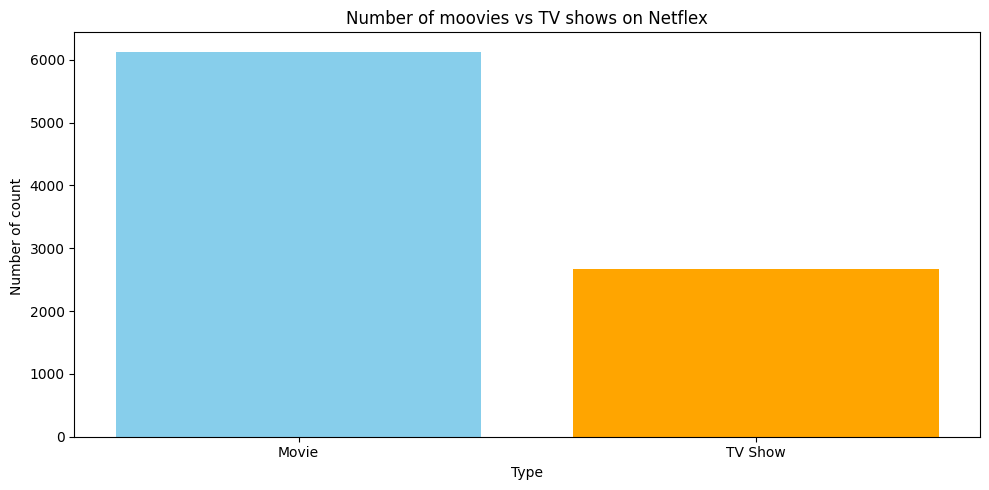

In [22]:
type_counts = df["type"].value_counts()
plt.figure(figsize=(10,5))
plt.bar(type_counts.index , type_counts.values, color = ["skyblue", "orange"], )
plt.title("Number of moovies vs TV shows on Netflex")
plt.xlabel("Type")
plt.ylabel("Number of count ")
plt.tight_layout()
plt.show()

## Rating count s

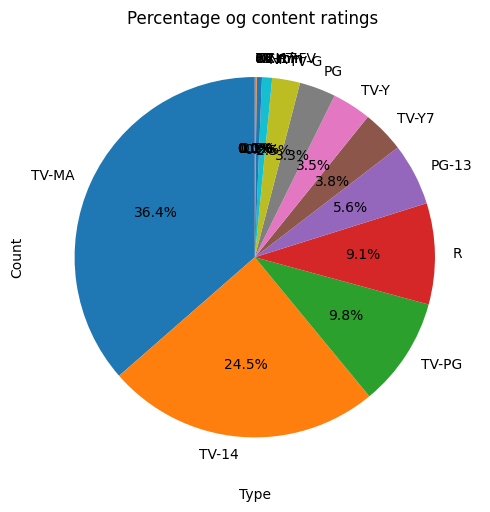

In [27]:
rating_count = df["rating"].value_counts()
plt.figure(figsize=(5,30))
plt.pie(rating_count , labels=rating_count.index , autopct="%1.1f%%", startangle=90)
plt.title("Percentage og content ratings ")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

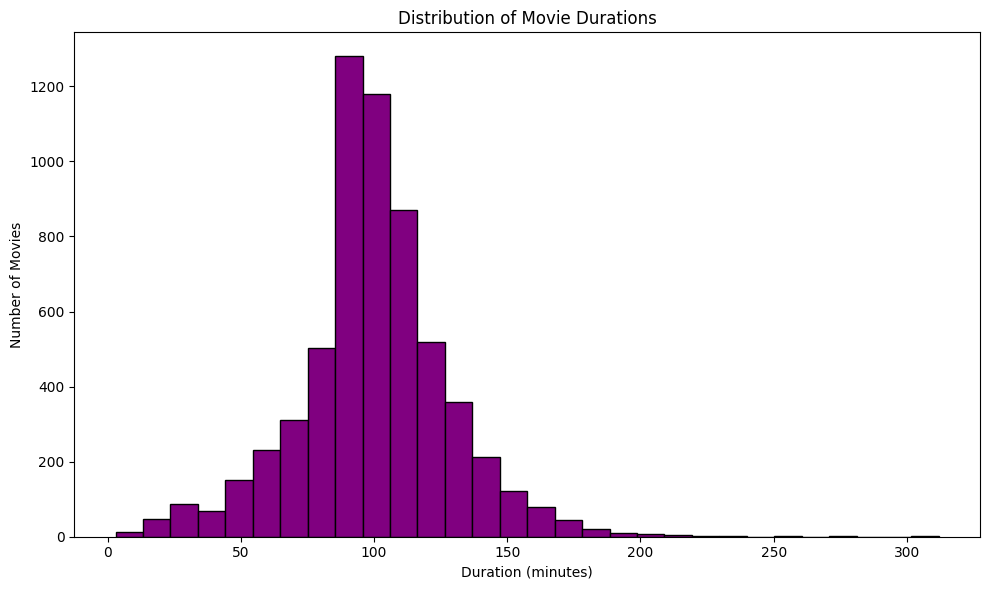

In [35]:
movie_df = df[df["type"] == "Movie"].copy()

# Remove rows where duration is NaN
movie_df = movie_df.dropna(subset=["duration"])

# Remove " min" and convert to int
movie_df["duration_int"] = movie_df["duration"].str.replace(" min", "", regex=False).astype(int)

# Plot the histogram using duration_int (which is numeric)
plt.figure(figsize=(10, 6))
plt.hist(movie_df["duration_int"], bins=30, color="purple", edgecolor="black")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


### Relise year vs number of shows 

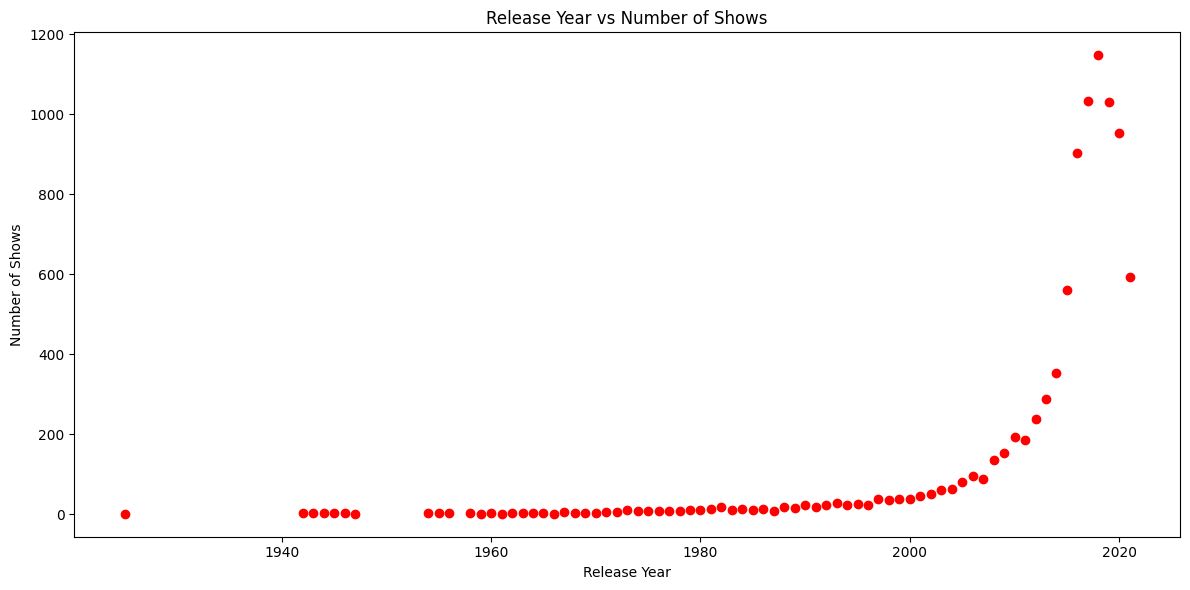

In [37]:
# relase_counts = df["release_year"].value_counts().sort_index()
# plt.figure(figsize=(20,20))
# plt.scatter(relase_counts.index , relase_counts.value_counts , color = "red")
# plt.title("Relase years vs Number of shows ")
# plt.xlabel("Relase Year")
# plt.ylabel("Number of shows ")
# plt.tight_layout()
# plt.show()
relase_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.scatter(relase_counts.index, relase_counts.values, color="red")
plt.title("Release Year vs Number of Shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()


## Top Countries Number of showa

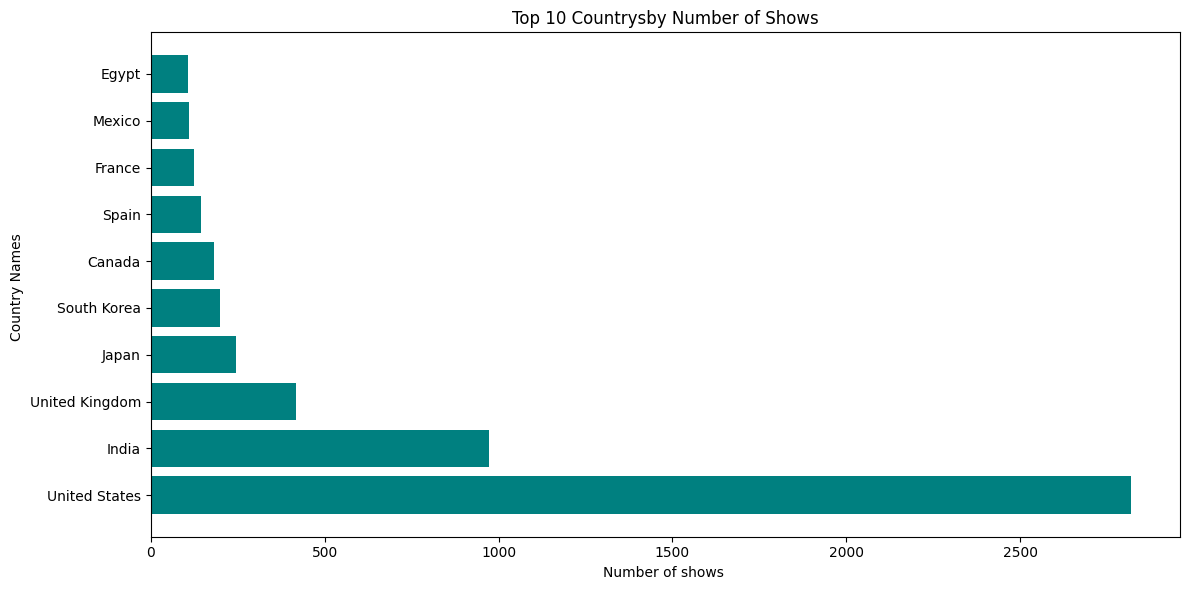

In [38]:
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(country_counts.index, country_counts.values, color="teal")
plt.title("Top 10 Countrysby Number of Shows")
plt.xlabel("Number of shows ")
plt.ylabel("Country Names ")
plt.tight_layout()
plt.show()


AttributeError: module 'matplotlib.pyplot' has no attribute 'subtitle'

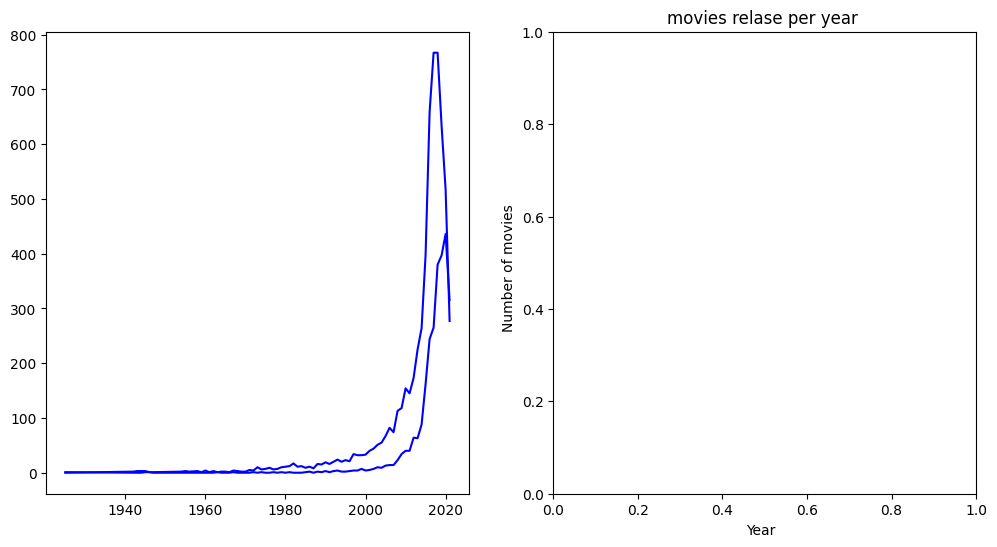

In [39]:
countent_by_year = df.groupby(["release_year","type"]).size().unstack().fillna(0)

fix , ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].plot(countent_by_year.index, countent_by_year["Movie"], color="blue")
plt.title("movies relase per year ")
plt.xlabel("Year  ")
plt.ylabel("Number of movies  ")


ax[0].plot(countent_by_year.index, countent_by_year["TV Show"], color="blue")
plt.title("movies relase per year ")
plt.xlabel("Year  ")
plt.ylabel("Number of movies  ")


plt.subtitle("Compersion of movies and tv shows released over year ")
plt.tight_layout()
plt.show()

